# Importing Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import re
from datetime import datetime
import calendar
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# Importing Dataset

In [2]:
shark_data = pd.read_pickle("./Data/shark_data_clean.pkl")

In [3]:
shark_data.head()

,date,year,attack_type,country,state,location,activity,gender,injury,fatal_yes_no,time,hemisphere,month,time_of_day,season
0,18th March,2026,Unprovoked,usa,California,Big River Beach Mendocino County,surfing,M,Injuries to both legs and feet,No,1715hrs,Northern,March,Afternoon,Winter
1,14th March,2026,Unprovoked,australia,Western Australia,Exmouth,swimming,F,Minor injuries,No,1015hrs,Southern,March,Morning,Summer
2,10th March,2026,Unprovoked,australia,Western Australia,Exmouth,wing foiling,M,None reported damage to board,No,0800hrs,Southern,March,Morning,Summer
3,5th March,2026,Unprovoked,australia,Queensland,Lady Elliott Island,snorkeling,M,Lacerations elbow and abdomen,No,0815hrs,Southern,March,Morning,Summer
4,22nd February,2026,Unprovoked,new caledonia,Noumea,Anse Vata near Point Magnin,wing foiling,M,Deep wounds arms and legs,Yes,?,Northern,February,NaN,Winter


In [4]:
# new dataframe to 1976 for more current data for analysis
shark_data = shark_data[shark_data["year"] >= 1976]

In [5]:
# checking the new dataframe size
shark_data.shape

(3952, 15)

# Analysis

## WHEN?

### Shark attacks are more likely to occur during summer months than winter months at each destination.

In [6]:
# checking mode for column season
shark_data['season'].mode()

0    Summer
Name: season, dtype: object

In [7]:
# checking count for column seasons
shark_data['season'].value_counts()

season
Summer    1482
Spring    1034
Autumn     780
Winter     627
Name: count, dtype: int64

C:\Users\gabri\AppData\Local\Temp\ipykernel_26016\78379007.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  season_bar = sns.countplot(x='season', data=shark_data, order=season_order, palette=['#042C53', '#0C447C', '#185FA5', '#378ADD'])


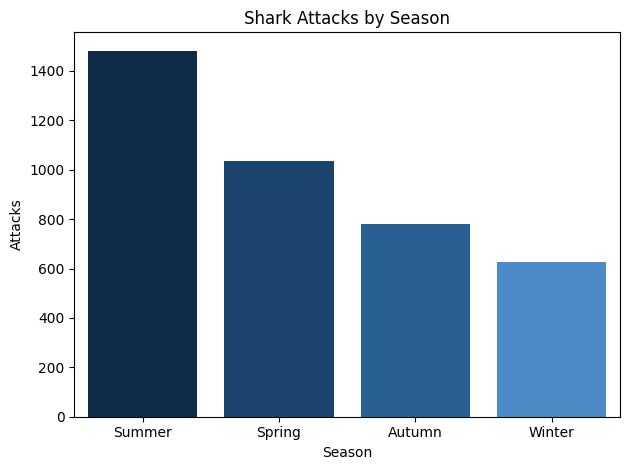

In [8]:
# plotting a bar chart of column seasons with the counts

# defining the order for plotting
season_order = shark_data['season'].value_counts().index

# plotting
season_bar = sns.countplot(x='season', data=shark_data, order=season_order, palette=['#042C53', '#0C447C', '#185FA5', '#378ADD'])

# structuring the viz
season_bar.set_title('Shark Attacks by Season')
season_bar.set_xlabel('Season')
season_bar.set_ylabel('Attacks')

plt.tight_layout()
plt.show()

In [9]:
# exporting the plot
season_bar.figure.savefig(('./Plots/season_bar.png'))

In [10]:
# building table with hemisphere and season - by counts

season_hemisphere_counts = pd.crosstab(shark_data['season'], shark_data['hemisphere'])

season_hemisphere_counts

hemisphere,Northern,Southern
season,,
Autumn,475,305
Spring,650,384
Summer,975,507
Winter,343,284


In [11]:
# building table season per hemisphere - by perc

season_hemisphere_perc = pd.crosstab(shark_data['season'], shark_data['hemisphere'], normalize='index')

season_hemisphere_perc

hemisphere,Northern,Southern
season,,
Autumn,0.608974,0.391026
Spring,0.628627,0.371373
Summer,0.657895,0.342105
Winter,0.547049,0.452951


In [12]:
# building table hemisphere per season - by perc

hemisphere_season_perc = pd.crosstab(shark_data['hemisphere'], shark_data['season'], normalize='index')

hemisphere_season_perc

season,Autumn,Spring,Summer,Winter
hemisphere,,,,
Northern,0.194433,0.266066,0.399099,0.140401
Southern,0.206081,0.259459,0.342568,0.191892


### Shark attacks are more likely to occur during afternoon hours than any other time of day. 

In [13]:
# checking count for time_of_day seasons
shark_data['time_of_day'].value_counts()

time_of_day
Afternoon    1372
Morning       911
Evening       258
Night          52
Name: count, dtype: int64

C:\Users\gabri\AppData\Local\Temp\ipykernel_26016\664597747.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  tod_bar = sns.countplot(x='time_of_day', data=shark_data, order=tod_order, palette=['#042C53', '#0C447C', '#185FA5', '#378ADD'])


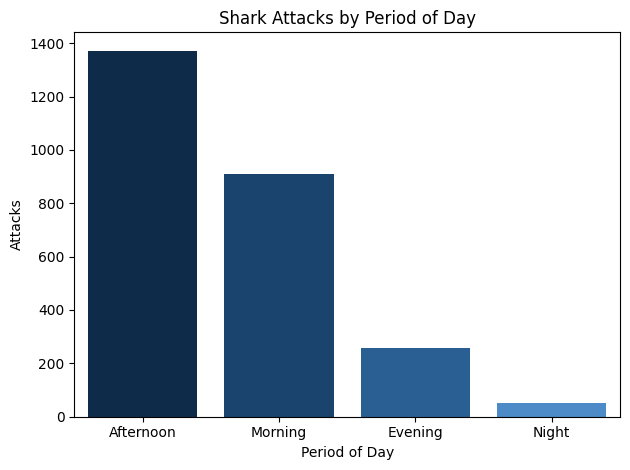

In [14]:
# plotting a bar chart of time_of_day with the counts

# defining the order for plotting
tod_order = shark_data['time_of_day'].value_counts().index

# plotting
tod_bar = sns.countplot(x='time_of_day', data=shark_data, order=tod_order, palette=['#042C53', '#0C447C', '#185FA5', '#378ADD'])

# structuring the viz
tod_bar.set_title('Shark Attacks by Period of Day')
tod_bar.set_xlabel('Period of Day')
tod_bar.set_ylabel('Attacks')

plt.tight_layout()
plt.show()

In [15]:
# exporting the plot
tod_bar.figure.savefig(('./Plots/tod_bar.png'))

## WHAT?

### Swimming is the activity with the highest number of shark attacks due to being a commum activity in water.

In [16]:
# defining of the top 5 activities, excluding null values

top_5_activities = shark_data['activity'].value_counts(dropna=True).head(5)

top_5_activities

activity
surfing         1089
swimming         553
spearfishing     259
fishing          234
snorkeling       132
Name: count, dtype: int64

In [17]:
# defining function to group everything that is not top 5 into other. 

def top_5_other(activity):
    if pd.isna(activity):
        return np.nan
    elif activity in top_5_activities:
        return activity
    else:
        return 'other'

In [18]:
# creating a new column activity_grouped
shark_data['activity_grouped'] = shark_data['activity'].apply(top_5_other)

In [19]:
# creating a table with top activities

activity_top_other = shark_data['activity_grouped'].value_counts().reset_index()
activity_top_other.columns = ['Activity', 'Count']
activity_top_other

,Activity,Count
0,other,1474
1,surfing,1089
2,swimming,553
3,spearfishing,259
4,fishing,234
5,snorkeling,132


In [20]:
# creating a table with top activities without other

activity_top_wo_other = shark_data['activity_grouped'].value_counts().reset_index()
activity_top_wo_other.columns = ['Activity', 'Count']
activity_top_wo_other = activity_top_wo_other[activity_top_wo_other['Activity'] != 'other']
activity_top_wo_other

,Activity,Count
1,surfing,1089
2,swimming,553
3,spearfishing,259
4,fishing,234
5,snorkeling,132


C:\Users\gabri\AppData\Local\Temp\ipykernel_26016\147600866.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  activity_bar = sns.barplot(x='Activity', y='Count', data=activity_top_wo_other, palette=['#042C53', '#0C447C', '#185FA5', '#378ADD', '#85B7EB'])


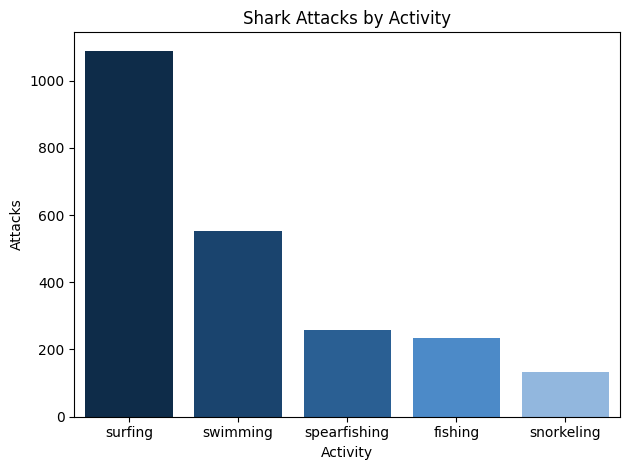

In [21]:
# plotting a bar chart of top activity with the counts

# defining the order for plotting
activity_bar = activity_top_wo_other['Activity'].value_counts().index

# plotting
activity_bar = sns.barplot(x='Activity', y='Count', data=activity_top_wo_other, palette=['#042C53', '#0C447C', '#185FA5', '#378ADD', '#85B7EB'])

# structuring the viz
activity_bar.set_title('Shark Attacks by Activity')
activity_bar.set_xlabel('Activity')
activity_bar.set_ylabel('Attacks')

plt.tight_layout()
plt.show()

In [22]:
# exporting the plot
activity_bar.figure.savefig(('./Plots/activity_bar.png'))

In [23]:
# finding counts for diving (curiosity, as not showing in top 5)

shark_data['activity'].value_counts()['diving']

np.int64(87)

In [24]:
# finding out the top 10 for presentation
top_10_activities = shark_data['activity'].value_counts(dropna=True).head(10)

top_10_activities

activity
surfing          1089
swimming          553
spearfishing      259
fishing           234
snorkeling        132
wading            129
scuba diving       90
diving             87
body boarding      69
standing           62
Name: count, dtype: int64

## WHERE?

### The USA, Australia and South Africa account for the highest number of shark attacks globally.

In [25]:
# defining of the top 10 countries, excluding null values (column has 0 null, but best practice just in case)

top_countries = shark_data['country'].value_counts(dropna=True).head(10)

top_countries

country
usa              1881
australia         713
south africa      349
brazil            113
bahamas           112
new zealand        72
new caledonia      59
reunion            58
mexico             50
egypt              36
Name: count, dtype: int64

In [26]:
# defining function to group everything that is not top 10 countries into other. 

def top_10_countries(country):
    if pd.isna(country):
        return np.nan
    elif country in top_countries:
        return country
    else:
        return 'other'

In [27]:
# creating a new column country_grouped 
shark_data['country_grouped'] = shark_data['country'].apply(top_10_countries)

In [28]:
# creating a table with top countries

country_top_other = shark_data['country_grouped'].value_counts().reset_index()
country_top_other.columns = ['Country', 'Count']
country_top_other

,Country,Count
0,usa,1881
1,australia,713
2,other,509
3,south africa,349
4,brazil,113
5,bahamas,112
6,new zealand,72
7,new caledonia,59
8,reunion,58
9,mexico,50


In [29]:
# creating a table with top countries without other

country_top_wo_other = shark_data['country_grouped'].value_counts().reset_index()
country_top_wo_other.columns = ['Country', 'Count']
country_top_wo_other = country_top_wo_other[country_top_wo_other['Country'] != 'other']
country_top_wo_other

,Country,Count
0,usa,1881
1,australia,713
3,south africa,349
4,brazil,113
5,bahamas,112
6,new zealand,72
7,new caledonia,59
8,reunion,58
9,mexico,50
10,egypt,36


C:\Users\gabri\AppData\Local\Temp\ipykernel_26016\167558668.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  country_bar = sns.barplot(x='Country', y='Count', data=country_top_wo_other, palette=['#042C53', '#0C447C', '#185FA5', '#378ADD', '#85B7EB'])
C:\Users\gabri\AppData\Local\Temp\ipykernel_26016\167558668.py:7: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  country_bar = sns.barplot(x='Country', y='Count', data=country_top_wo_other, palette=['#042C53', '#0C447C', '#185FA5', '#378ADD', '#85B7EB'])


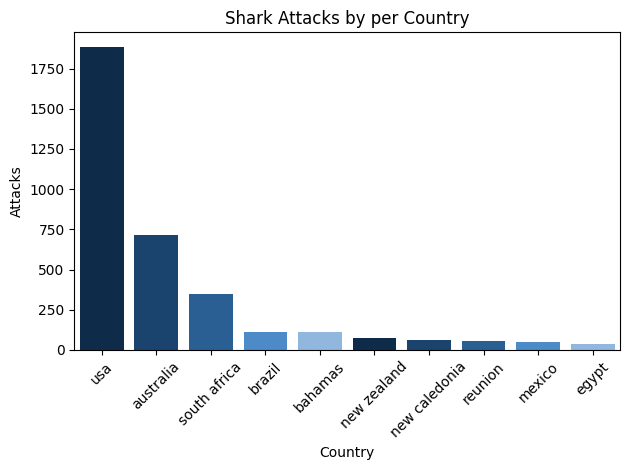

In [30]:
# plotting a bar chart of top country with the counts

# defining the order for plotting
country_bar = country_top_wo_other['Country'].value_counts().index

# plotting
country_bar = sns.barplot(x='Country', y='Count', data=country_top_wo_other, palette=['#042C53', '#0C447C', '#185FA5', '#378ADD', '#85B7EB'])

# structuring the viz
country_bar.set_title('Shark Attacks by per Country')
country_bar.set_xlabel('Country')
country_bar.set_ylabel('Attacks')
country_bar.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [31]:
# exporting the plot
country_bar.figure.savefig(('./Plots/country_bar.png'))

In [32]:
# dividing the data to get only top 3 countries data

top_3 = country_top_wo_other['Country'].head(3).tolist()
shark_data_top3 = shark_data[shark_data['country_grouped'].isin(top_3)]

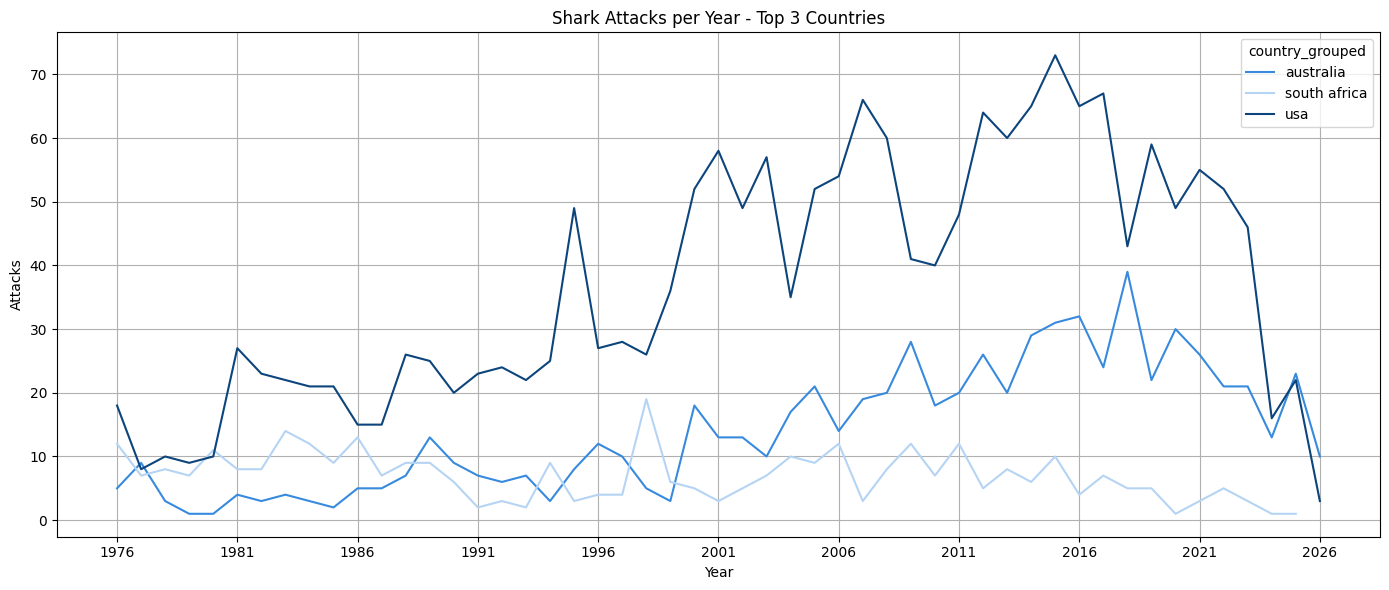

In [33]:
# plotting a timeseries of attacks per year on top 10 countries
country_year = shark_data_top3.groupby(['year', 'country_grouped']).size().unstack()

# plotting
top_3_timeseries = country_year.plot(figsize=(14,6), title='Shark Attacks per Year - Top 3 Countries', color=['#378ADD', '#B5D4F4', '#0C447C'])

# structuring the viz
plt.xticks(range(1976, 2027, 5))
plt.ylabel('Attacks')
plt.xlabel('Year')
plt.grid(which='both', axis='both')
plt.tight_layout()
plt.show()

In [34]:
# exporting the plot
top_3_timeseries.figure.savefig(('./Plots/top_3_timeseries.png'))

In [35]:
# finding out which are the most fatal activities in the top 3 countries

fatal_activities = shark_data[
    (shark_data["country"].isin(top_3)) &
    (shark_data["fatal_yes_no"] == "Yes")
]["activity"].value_counts().head(3)

fatal_activities

activity
surfing         41
swimming        36
spearfishing    12
Name: count, dtype: int64

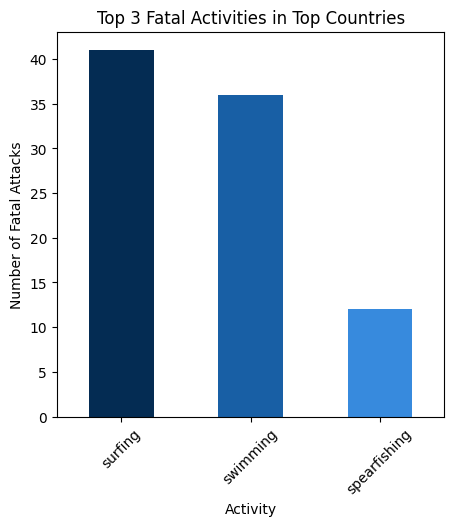

In [36]:
# plotting the most fatal activity in top 3 countries

fatal_activities_bar = fatal_activities.plot(kind="bar", figsize=(5,5), color=["#042C53", "#185FA5", "#378ADD"])

plt.title("Top 3 Fatal Activities in Top Countries")
plt.xlabel("Activity")
plt.ylabel("Number of Fatal Attacks")
plt.xticks(rotation=45)

plt.show()

In [37]:
# exporting the plot
fatal_activities_bar.figure.savefig(('./Plots/fatal_activities_bar.png'))

###  Shark attacks have increased over time, not only on top destinations, but globally

In [38]:
# checking last 30 years of attacks to find pattern

attacks_per_year = shark_data["year"].value_counts().sort_index()
attacks_per_year.tail(30)

year
1997     57
1998     65
1999     66
2000     97
2001     92
2002     88
2003     92
2004     92
2005    103
2006    103
2007    113
2008    122
2009    120
2010    101
2011    128
2012    117
2013    122
2014    125
2015    143
2016    133
2017    140
2018    124
2019    114
2020    101
2021    111
2022     98
2023    109
2024     52
2025     68
2026     19
Name: count, dtype: int64

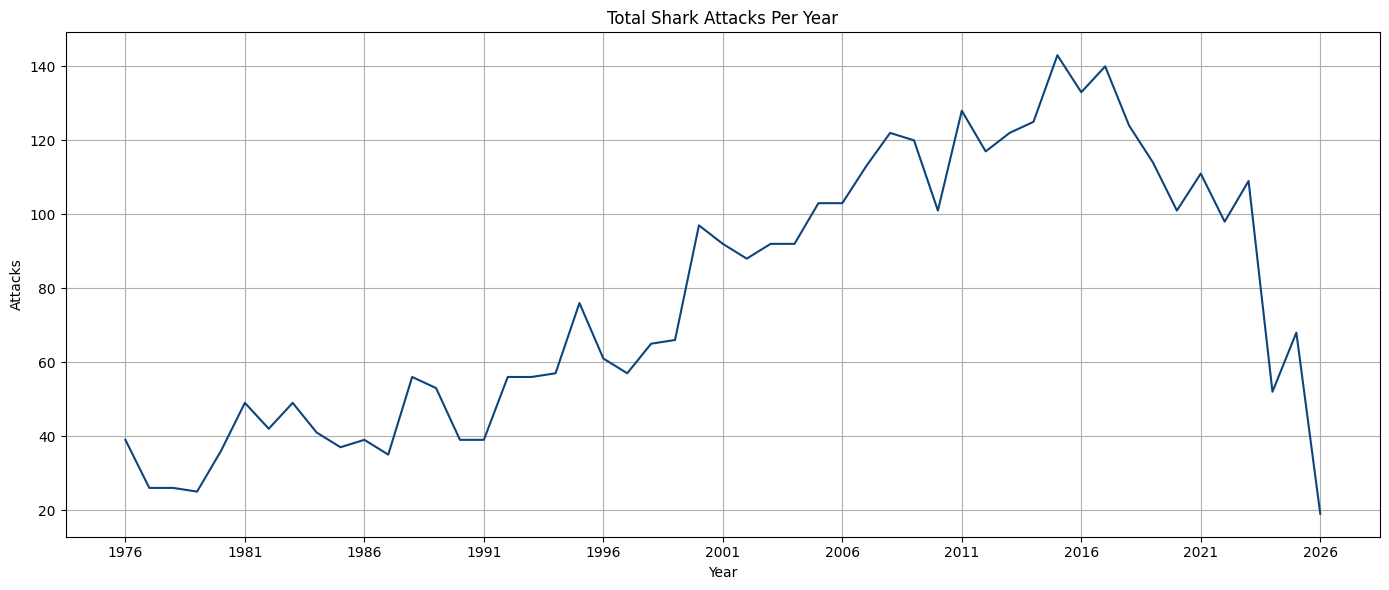

In [39]:
# plotting a timeseries of attacks per year
time_series_attack = attacks_per_year.plot(figsize=(14,6), title="Total Shark Attacks Per Year", color='#0C447C')

# structuring the viz
plt.xticks(range(1976, 2027, 5))  
plt.ylabel('Attacks')
plt.xlabel('Year')
plt.grid(which='both', axis='both')

plt.tight_layout()
plt.show()

In [40]:
# exporting the plot
time_series_attack.figure.savefig(('./Plots/time_series_attack.png'))

In [41]:
shark_data.shape

(3952, 17)